Conclusion #3: Parental level of education has no effect on student lunch plan.

Hypothesis test used to interpret conclusion #3: Chi-Squared Test

Null Hypothesis (Ho): Parental level of education has no effect on student lunch plan
Alternative Hypothesis (Ha): Parental level of education has an effect on student lunch plan

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [4]:
# Load the dataset
df = pd.read_csv("../data/StudentsPerformance.csv")


In [5]:
# Make column names into one string
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Rename some columns with a better description
df = df.rename(columns = {
    "race/ethnicity": "race",
    "lunch": "lunch_plan",
    "test_preparation_course": "test_prep_status"
})

In [44]:
# The scores are good already since they are integers. We need to make the first five columns into categorical data types, though.
categorical_columns = [
    "gender", "race", "parental_level_of_education",
    "lunch_plan", "test_prep_status"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df.dtypes

,0
gender,category
race,category
parental_level_of_education,category
lunch_plan,category
test_prep_status,category
math_score,int64
reading_score,int64
writing_score,int64


In [ ]:
# Hypothesis testing: Chi-squared test


contingency_table = pd.crosstab(df["parental_level_of_education"], df["lunch_plan"])
stat, p, dof, expected = chi2_contingency(contingency_table)
print(f"P-value: {p}")
print("Using an alpha value of 0.05, we find that the p-value is greater than 0.05, meaning that the data is not significant and we accept the null hypothesis. \nParental level of education has no effect on student lunch plan.")

P-value: 0.9531014927218224
Using an alpha value of 0.05, we find that the p-value is greater than 0.05, meaning that the data is not significant and we accept the null hypothesis. 
Parental level of education has no effect on student lunch plan.


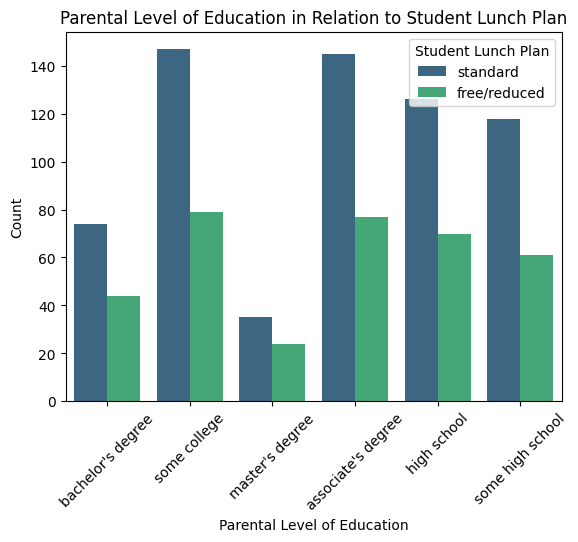

In [7]:
# Plotting relationship between parental level of education and lunch plan
sns.countplot(data = df, x = "parental_level_of_education", hue = "lunch_plan", palette = "viridis")
plt.xticks(rotation = 45)
plt.xlabel("Parental Level of Education")
plt.ylabel("Count")
plt.title("Parental Level of Education in Relation to Student Lunch Plan")
plt.legend(title = "Student Lunch Plan")